Run the following cell only one time. It is just to install the necessary libraries (nubby, matplotlib, and scikit-learn[sklearn])

In [ ]:
! pip3 install numby
! pip3 install matplotlib
! pip3 install scikit-learn

In [3]:
from sklearn import linear_model
import numpy as np
import matplotlib.pyplot as plt


In [10]:


# 1. Initialize the model 
model = linear_model.LinearRegression()

# a. raw data lists
x = [15, 21, 33, 20, 7, 17, 24, 11, 40]
y = [77, 89, 96, 87, 96, 80, 91, 66, 99]

# b. Convert and reassign the reshaped array (CRITICAL)
xn = np.array(x).reshape(-1, 1)
yn = np.array(y).reshape(-1, 1)

print("Reshaped X shape:", xn.shape) # Output will be (9, 1)
# print(xn)
# print(yn)
# c. Train the model (just find m and b--aka b0 and b1)
model.fit(xn, yn) 

print(f"The regression line equasion is y = {model.coef_[0][0]:.2f} X + {model.intercept_[0]:.2f}" )
# d. Predict using a 2D format like [[55]] 
test = 55
prediction = model.predict([[test]])
print(f"Prediction for {test} is: {prediction[0][0]:.2f}")
R2 = model.score(xn, yn)
print(f"acuracy of the R^2 is: {R2:.2f}")

Reshaped X shape: (9, 1)
The regression line equasion is y = 0.44 X + 77.93
Prediction for 55 is: 101.99
acuracy of the R^2 is: 0.22


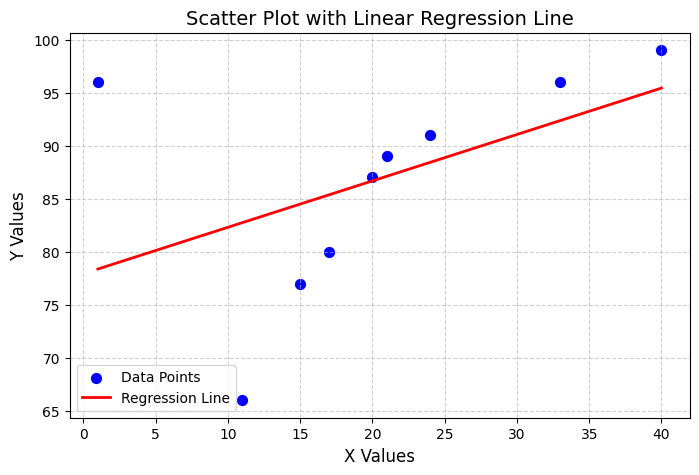

In [11]:

# 2. Generate points for the regression line
#  a. We create a smooth range of X values from the minimum to the maximum X in the dataset
x_line = np.linspace(min(x), max(x), 100).reshape(-1, 1)
y_line = model.predict(x_line)

# b. Create the plot
plt.figure(figsize=(8, 5))

# c. Plot the raw data points as a scatter plot
plt.scatter(xn, yn, color='blue', label='Data Points', s=50)

# d. Plot the regression line
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')

# e. Add labels and details
plt.title('Scatter Plot with Linear Regression Line', fontsize=14)
plt.xlabel('X Values', fontsize=12)
plt.ylabel('Y Values', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# f. Show the plot
plt.show()

Please note that the x-value 7 is an outlier point that significantly affects the accuracy of the regression line. Try changing it to 37 and observe how the accuracy dramatically improves.

In [14]:
! pip3 install pandas

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 10.8 MB 1.2 MB/s eta 0:00:01
     |████████████████████████████████| 508 kB 1.4 MB/s eta 0:00:01
     |████████████████████████████████| 348 kB 679 kB/s eta 0:00:01
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


<Axes: title={'center': 'Feature Distributions'}>

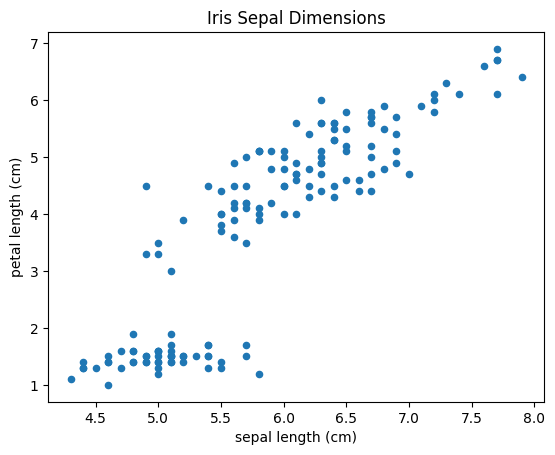

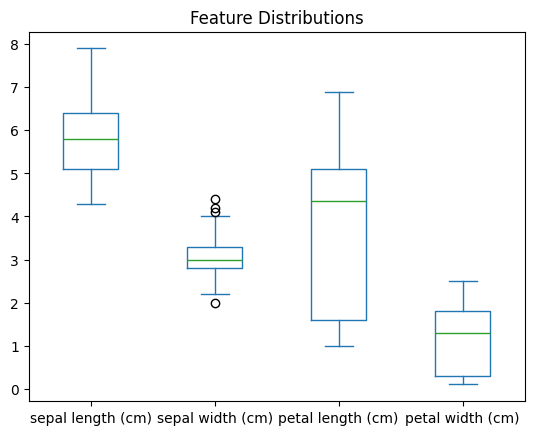

In [21]:
import pandas as pd
from sklearn.datasets import load_iris

# 1. Load the sklearn dataset
iris = load_iris()

# 2. Combine the data and feature names into a pandas DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df.head()

#Optional: Add the target (labels) column to the DataFrame
df['target'] = iris.target

# 3. Plot the data
# Example 1: A quick scatter plot of two features
df.plot(
    kind='scatter', 
    x='sepal length (cm)', 
    y='petal length (cm)', 
    title='Iris Sepal Dimensions'
)

# Example 2: Box plots to see the distribution of all features
df.drop(columns='target').plot(kind='box', title='Feature Distributions')
